# Differential expression analysis using NCBI SRA gene-count files

## Introduction

In this tutorial, we will use public SRA RNA-seq data to compare gene expression between two experimental conditions using NCBI-provided gene-count files. Rather than downloading raw sequencing reads and running a full alignment and quantification workflow, we will take advantage of precomputed gene counts available through the NCBI SRA RNA-seq analysis resource.

We will begin with an SRA study accession and define the control and treatment groups to compare. From there, we will retrieve run-level metadata, connect SRA Run accessions to their corresponding BioSample records, and extract treatment information from BioSample attributes. We will then link each run to its gene-count TSV file in the public SRA RNA-seq analysis bucket.

After collecting the count files, we will build two key inputs for differential expression analysis: a gene-by-sample count matrix and a sample metadata table describing the experimental condition for each run. Finally, we will use DESeq2 through PyDESeq2 to identify genes that are differentially expressed between the selected conditions and generate summary output files and plots for interpreting the results.

By the end of this tutorial, you will have a complete workflow for going from an SRA study accession to a differential expression results table using publicly available NCBI gene counts.


## Data availability

NCBI provides precomputed RNA-seq gene-count files for publicly available SRA data. This resource currently includes both human and mouse RNA-seq datasets, making it possible to analyze many studies without starting from raw sequencing reads.

The dataset is updated regularly as new RNA-seq data become available and are processed through the NCBI workflow. Because the available files may change over time, it is useful to check the current file listing before beginning an analysis.

The workflow used to generate these gene-count files is publicly available on GitHub at:

`https://github.com/ncbi/rnaseq_gene_counts`

The processed gene-count TSV files are stored in the public S3 location:

`s3://sra-rnaseq-analysis/tsv/`

The same files can also be accessed over HTTPS using URLs beginning with:

`https://sra-rnaseq-analysis.s3.amazonaws.com/`

The complete file listing is available at:

`s3://sra-rnaseq-analysis/content.tsv`

or by HTTPS at:

`https://sra-rnaseq-analysis.s3.amazonaws.com/content.tsv`

In this tutorial, we will use this public file listing to identify which SRA runs have precomputed gene-count files and then download the files needed for our selected study.


## Setup environment

This notebook uses PyDESeq2, a Python implementation of the DESeq2 workflow. The package versions below are pinned because PyDESeq2 depends on specific compatible versions of NumPy, pandas, SciPy, anndata, and numba.

This setup cell is intended for a fresh notebook environment, such as Google Colab. If you are running this notebook in an existing Python environment, review the package changes before running the uninstall command.

In [ ]:
%%capture
%pip uninstall -qqq -y pydeseq2 anndata pandas numpy scipy numba
%pip install -qqq --progress-bar off --no-cache-dir \
  "numpy>=1.26,<2.1" \
  "pandas==2.2.2" \
  "scipy>=1.12,<1.15" \
  "numba==0.60.0" \
  "anndata<0.12" \
  "pydeseq2==0.5.2"

Install NCBI Entrez Direct tools

In [ ]:
!curl -qfsSL https://ftp.ncbi.nlm.nih.gov/entrez/entrezdirect/install-edirect.sh | bash > /dev/null

After installing these packages, the Python session must be restarted so the notebook loads the newly installed versions. Run the next cell once. The session will stop, which is expected. Then continue running the notebook from the following section.

In [ ]:
import os
os.kill(os.getpid(), 9)

After installing the dependencies, continue from this cell:

In [ ]:
import os
os.environ["PATH"] = f"/root/edirect:{os.environ['PATH']}"

## Collect metadata

Start by choosing an SRA study that contains RNA-seq data for the experiment you want to analyze. Then decide which samples belong to the control group and which samples belong to the treatment group. The control group is the baseline or comparison group, while the treatment group is the condition you want to compare against it.

Choose which condition will be used as the baseline and which will be compared against it. Here, "ESC culture (+LIF, 2i)" is the control because these cells are maintained in embryonic stem cell culture conditions. "Differentiation (-LIF, 2i)" is the treated condition because LIF has been removed, which promotes differentiation.

See the publication for details:
https://pubmed.ncbi.nlm.nih.gov/39605346/

In [ ]:
study='SRP537246'

control_level="ESC culture (+LIF, 2i)"
treated_level="Differentiation (-LIF, 2i)"

In [ ]:
import subprocess
from io import StringIO

import numpy as np
import pandas as pd

def sra_study_runs_biosamples(study_accession: str) -> pd.DataFrame:
    """
    Return a dataframe of SRA Run and BioSample accession pairs for an SRA study accession
    """
    study_accession = study_accession.strip()

    cmd = f'esearch -db sra -query "{study_accession}" | efetch -format runinfo'
    out = subprocess.check_output(cmd, shell=True, text=True)

    df = pd.read_csv(StringIO(out), dtype=str)

    # Keep only the run and biosample columns:
    keep = [c for c in ["Run", "BioSample"] if c in df.columns]
    df = df[keep].dropna(how="all").drop_duplicates().reset_index(drop=True)

    return df

Collect all SRA runs with corresponding biosamples in `run_biosample` dataframe:

In [ ]:
run_biosample = sra_study_runs_biosamples(study)

Next, we look in the BioSample metadata for an attribute whose name contains the word “treat”. In many SRA studies, treatment or condition information is stored in a BioSample attribute such as `treatment`, `treatment group`, or `cancer treatment`.

This automated search works for this example study, but metadata fields are not standardized across all studies. For other datasets, you may need to manually inspect the BioSample attributes to find the column that defines the control and treatment groups.

In [ ]:
# BioSample <-> treatment
cmd = rf"""
esearch -db sra -query {study} |
elink -target biosample |
efetch -format docsum |
xtract \
    -pattern DocumentSummary \
    -element Accession \
    -block Attribute \
    -if @attribute_name -contains treat \
    -element Attribute
"""

biosample_treatment = pd.read_csv(
    StringIO(subprocess.check_output(cmd, shell=True, text=True)),
    sep="\t",
    names=["BioSample", "Treatment"]
)

# join run accessions with sample treatment:
run_treatment = run_biosample.merge(biosample_treatment, on="BioSample", how="inner")

The dataframe `run_treatment` now contains columns:
*   `Run` - run accession
*   `BioSample` - biosample accession
*   `Treatment` - control/treatment condition

This metadata should be sufficient for DESeq2.

In [ ]:
print(
    run_treatment["Treatment"]
    .value_counts()
    .rename_axis("value")
    .reset_index(name="count")
)

# check for runs without treatment, this is useful to confirm that the treatment look up worked correctly:
observed_levels = set(run_treatment["Treatment"].dropna())

missing_levels = {control_level, treated_level} - observed_levels
if missing_levels:
    raise ValueError(
        "The selected control/treatment level(s) were not found in the metadata: "
        f"{missing_levels}\n\nObserved treatment values are:\n"
        + "\n".join(sorted(observed_levels))
    )

                             value  count
0           ESC culture (+LIF, 2i)     22
1  Differentiation (-LIF, 2i; +RA)      9
2       Differentiation (-LIF, 2i)      8
3                  siControl siRNA      2
4                   siRING1B siRNA      2


Access the public SRA RNA-seq analysis bucket to read:
* listing of all gene counts TSV files available
* individual SRA run gene counts TSV files

The bucket content TSV listing is 7 columns:
* `Run` - SRA run accession (source of sequencing reads data)
* `Bioproject` - bioproject accession (sequencing project)
* `Biosample`- biosample accession (the sample sequenced)
* `Analysis` - SRA analysis accession
* `Organism` - Organism scientific name
* `Path` - relative path to the gene counts TSV file
* `MD5` - MD5 checksum for the gene counts TSV file

SRA gene counts file structure:
* TSV format
* first row is header
* columns:
  * NCBI geneid, integer
  * counts, float

In [ ]:

def fetch_tsv_paths_for_runs(
    runs: pd.DataFrame,
    url: str = "https://sra-rnaseq-analysis.s3.amazonaws.com/content.tsv",
    chunksize: int = 200_000,
) -> pd.DataFrame:
    """
    Return rows from content.tsv corresponding to runs["Run"].
    Stops reading once all requested runs have been found.
    """
    cols = ["Run", "Bioproject", "Biosample", "Analysis", "Organism", "Path", "MD5"]

    remaining = set(runs["Run"].astype(str))
    matches = []

    for chunk in pd.read_csv(
        url,
        sep="\t",
        header=None,
        names=cols,
        usecols=cols,
        dtype=str,
        chunksize=chunksize,
    ):
        matched = chunk[chunk["Run"].isin(remaining)]
        if matched.empty:
            continue

        matches.append(matched[["Run", "Path"]])
        remaining.difference_update(matched["Run"])

        if not remaining:
            break

    if not matches:
        return pd.DataFrame(columns=["Run", "Path", "Treatment"])

    return pd.concat(matches, ignore_index=True).merge(runs, on="Run", how="inner")

In [ ]:
run_treatment_tsv_path = fetch_tsv_paths_for_runs(run_treatment)

Check whether every selected run has an available gene-count TSV file.

A warning about `missing_runs` does not always mean something is wrong with the workflow. Some SRA studies include both transcriptomic runs, such as RNA-seq, and genomic runs, such as DNA-seq or other assay types. Genomic runs are not suitable for differential gene-expression analysis, so they may not have treatment metadata relevant to this tutorial and may not have NCBI gene-count TSV files.

If `missing_runs` is not empty, inspect those runs before continuing. Confirm whether they are non-transcriptomic runs that should be excluded, or whether they are RNA-seq runs that are missing expected metadata or count files. Only runs with appropriate transcriptomic data, valid condition labels, and available gene-count TSV files should be included in the DESeq2 analysis.

In this study (SRP537246/PRJNA1169811), only 24 runs are transcriptomic and suitable for differential expression analysis. The remaining 19 accessions are not included in the gene-count workflow, so they are reported in `missing_runs`.


In [ ]:
missing_runs = set(run_treatment["Run"]) - set(run_treatment_tsv_path["Run"])

if missing_runs:
    print(f"Warning: {len(missing_runs)} run(s) do not have available gene-count TSV files.")
    print(sorted(missing_runs)[:10])

print(f"Runs with treatment metadata: {run_treatment['Run'].nunique()}")
print(f"Runs with available gene-count files: {run_treatment_tsv_path['Run'].nunique()}")

['SRR30916784', 'SRR30916785', 'SRR30916786', 'SRR30916787', 'SRR30916788', 'SRR30916789', 'SRR30916790', 'SRR30916791', 'SRR31313779', 'SRR35038940']
Runs with treatment metadata: 43
Runs with available gene-count files: 24


## Collect data

Prepare data and metadata tables for DESeq2 call:

`counts_matrix`
* `geneid` - NCBI gene id
* N columns of counts, one for each run accession


`metadata`
 * `index` - run accessions, same values as the counts column names in `counts_matrix`
 * `Treatment` - control/treatment categories


In [ ]:
from pathlib import Path
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def read_counts_tsv(path: str) -> pd.Series:
    p = urlparse(path)
    if p.scheme == "s3":
        url = f"https://{p.netloc}.s3.amazonaws.com{p.path}"
    else:
        url = f"https://sra-rnaseq-analysis.s3.amazonaws.com/{path.lstrip('/')}"

    df = pd.read_csv(
        url,
        sep="\t",
        skiprows=1,
        header=None,
        names=["geneid", "counts"],
        dtype={"geneid": int, "counts": "float64"},
    )
    return df.set_index("geneid")["counts"]


def build_count_matrix(runs_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    required = {"Run", "Treatment", "Path"}
    missing = required - set(runs_df.columns)
    if missing:
        raise ValueError(f"runs_df is missing required columns: {sorted(missing)}")

    runs = runs_df[["Run", "Treatment", "Path"]].drop_duplicates("Run").copy()

    series_list = []
    for row in runs.itertuples(index=False):
        s = read_counts_tsv(row.Path)
        s.name = row.Run
        series_list.append(s)

    count_matrix = pd.concat(series_list, axis=1).fillna(0).astype(int)

    metadata = (
        runs.set_index("Run")
            .loc[count_matrix.columns, ["Treatment"]]
            .copy()
    )
    metadata["Treatment"] = metadata["Treatment"].astype("category")

    return count_matrix, metadata

In [ ]:
count_matrix, metadata = build_count_matrix(run_treatment_tsv_path)

## Run DESeq2

Now that the count data and sample information have been prepared, we are ready to run the differential expression analysis. This step uses DESeq2 to compare gene expression between the control and treatment groups.

DESeq2 takes the gene-count matrix and the sample metadata as input. It normalizes the counts to account for differences in sequencing depth between samples, estimates variation across biological replicates, and tests each gene to determine whether its expression is significantly different between the two conditions.

The output is a results table that includes, for each gene, the estimated change in expression between groups, a statistical significance value, and an adjusted significance value that accounts for testing many genes at once. These results will help us identify genes that are more highly expressed or less highly expressed in the treatment group compared with the control group.

In the DESeq2 results, `log2FoldChange` describes expression in the treated group relative to the control group. In this tutorial, a positive log2 fold change means the gene has higher expression in `Differentiation (-LIF, 2i)` than in `ESC culture (+LIF, 2i)`. A negative value means the gene has lower expression in the differentiation condition than in the ESC culture condition.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

def run_deseq2_and_save(
    count_matrix: pd.DataFrame,
    metadata: pd.DataFrame,
    outdir: str | Path,
    control_level: str = "Untreated",
    treated_level: str = "Treated",
    min_total_counts: int = 10,
    n_cpus: int = 4,
) -> pd.DataFrame:
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    # Optional gene filtering
    count_matrix = count_matrix.loc[count_matrix.sum(axis=1) >= min_total_counts]

    # PyDESeq2 expects samples x genes
    counts_for_deseq = count_matrix.T
    metadata_for_deseq = metadata.loc[counts_for_deseq.index]

    # Fit model
    dds = DeseqDataSet(
        counts=counts_for_deseq,
        metadata=metadata_for_deseq,
        design_factors="Treatment",
        ref_level=["Treatment", control_level],
        inference=DefaultInference(n_cpus=n_cpus),
        refit_cooks=True,
    )
    dds.deseq2()

    stats = DeseqStats(
        dds,
        contrast=["Treatment", treated_level, control_level],
        alpha=0.05,
    )
    stats.summary()

    # Results table
    res = stats.results_df.copy()
    res.to_csv(outdir / "deseq2_results.csv")
    res.to_parquet(outdir / "deseq2_results.parquet")

    # MA plot from PyDESeq2
    stats.plot_MA(save_path=str(outdir / "ma_plot.png"))

    # Volcano plot
    volcano = res.copy()
    volcano = volcano.dropna(subset=["log2FoldChange", "padj"])

    volcano["neglog10_padj"] = -np.log10(volcano["padj"].clip(lower=1e-300))
    volcano["significant"] = (volcano["padj"] < 0.05) & (volcano["log2FoldChange"].abs() >= 1)

    fig, ax = plt.subplots(figsize=(7, 6))
    nonsig = volcano.loc[~volcano["significant"]]
    sig = volcano.loc[volcano["significant"]]

    ax.scatter(
        nonsig["log2FoldChange"],
        nonsig["neglog10_padj"],
        s=10,
        alpha=0.5,
    )
    ax.scatter(
        sig["log2FoldChange"],
        sig["neglog10_padj"],
        s=10,
        alpha=0.8,
    )

    ax.axvline(1, linestyle="--")
    ax.axvline(-1, linestyle="--")
    ax.axhline(-np.log10(0.05), linestyle="--")
    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10(adjusted p-value)")
    ax.set_title("Volcano plot")

    fig.tight_layout()
    fig.savefig(outdir / "volcano_plot.png", dpi=300)
    plt.close(fig)

    return res


/usr/local/lib/python3.12/dist-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/tmp/ipykernel_43343/3173470563.py:31: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(
/tmp/ipykernel_43343/3173470563.py:31: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.05 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 57.49 seconds.

Fitting dispersion trend curve...
... done in 1.00 seconds.

Fitting MAP dispersions...
... done in 73.26 seconds.

Fitting LFCs...
... done in 34.38 seconds.

Calculating cook's distance...
... done in 0.10 seconds.

Replacing 159 outlier genes.

Fitting dispersions...
... done in 0.54 seconds.

Fitting MAP dispersions...
... done in 0.57 seconds.

Fitting LFCs...
... done in 0.40 seconds.

Running Wald tests...
... done in 10.38 seconds.



Log2 fold change & Wald test p-value: Treatment Differentiation (-LIF, 2i) vs ESC culture (+LIF, 2i)
                baseMean  log2FoldChange     lfcSE      stat        pvalue  \
geneid                                                                       
497097        145.885089        2.186921  0.378485  5.778093  7.555219e-09   
118567655       7.127266        0.887158  0.569336  1.558231  1.191786e-01   
664792          0.599052        0.357632  1.011494  0.353568  7.236626e-01   
19888          18.224740        0.159339  0.288012  0.553237  5.801008e-01   
20671         231.403970        5.216971  0.715858  7.287715  3.152559e-13   
...                  ...             ...       ...       ...           ...   
17722       15726.169995        0.264226  0.243422  1.085467  2.777147e-01   
17729        1248.780103        0.330981  0.365134  0.906465  3.646898e-01   
17711      109254.635008       -0.213282  0.160832 -1.326112  1.848027e-01   
17744          97.026653       -0.486988 

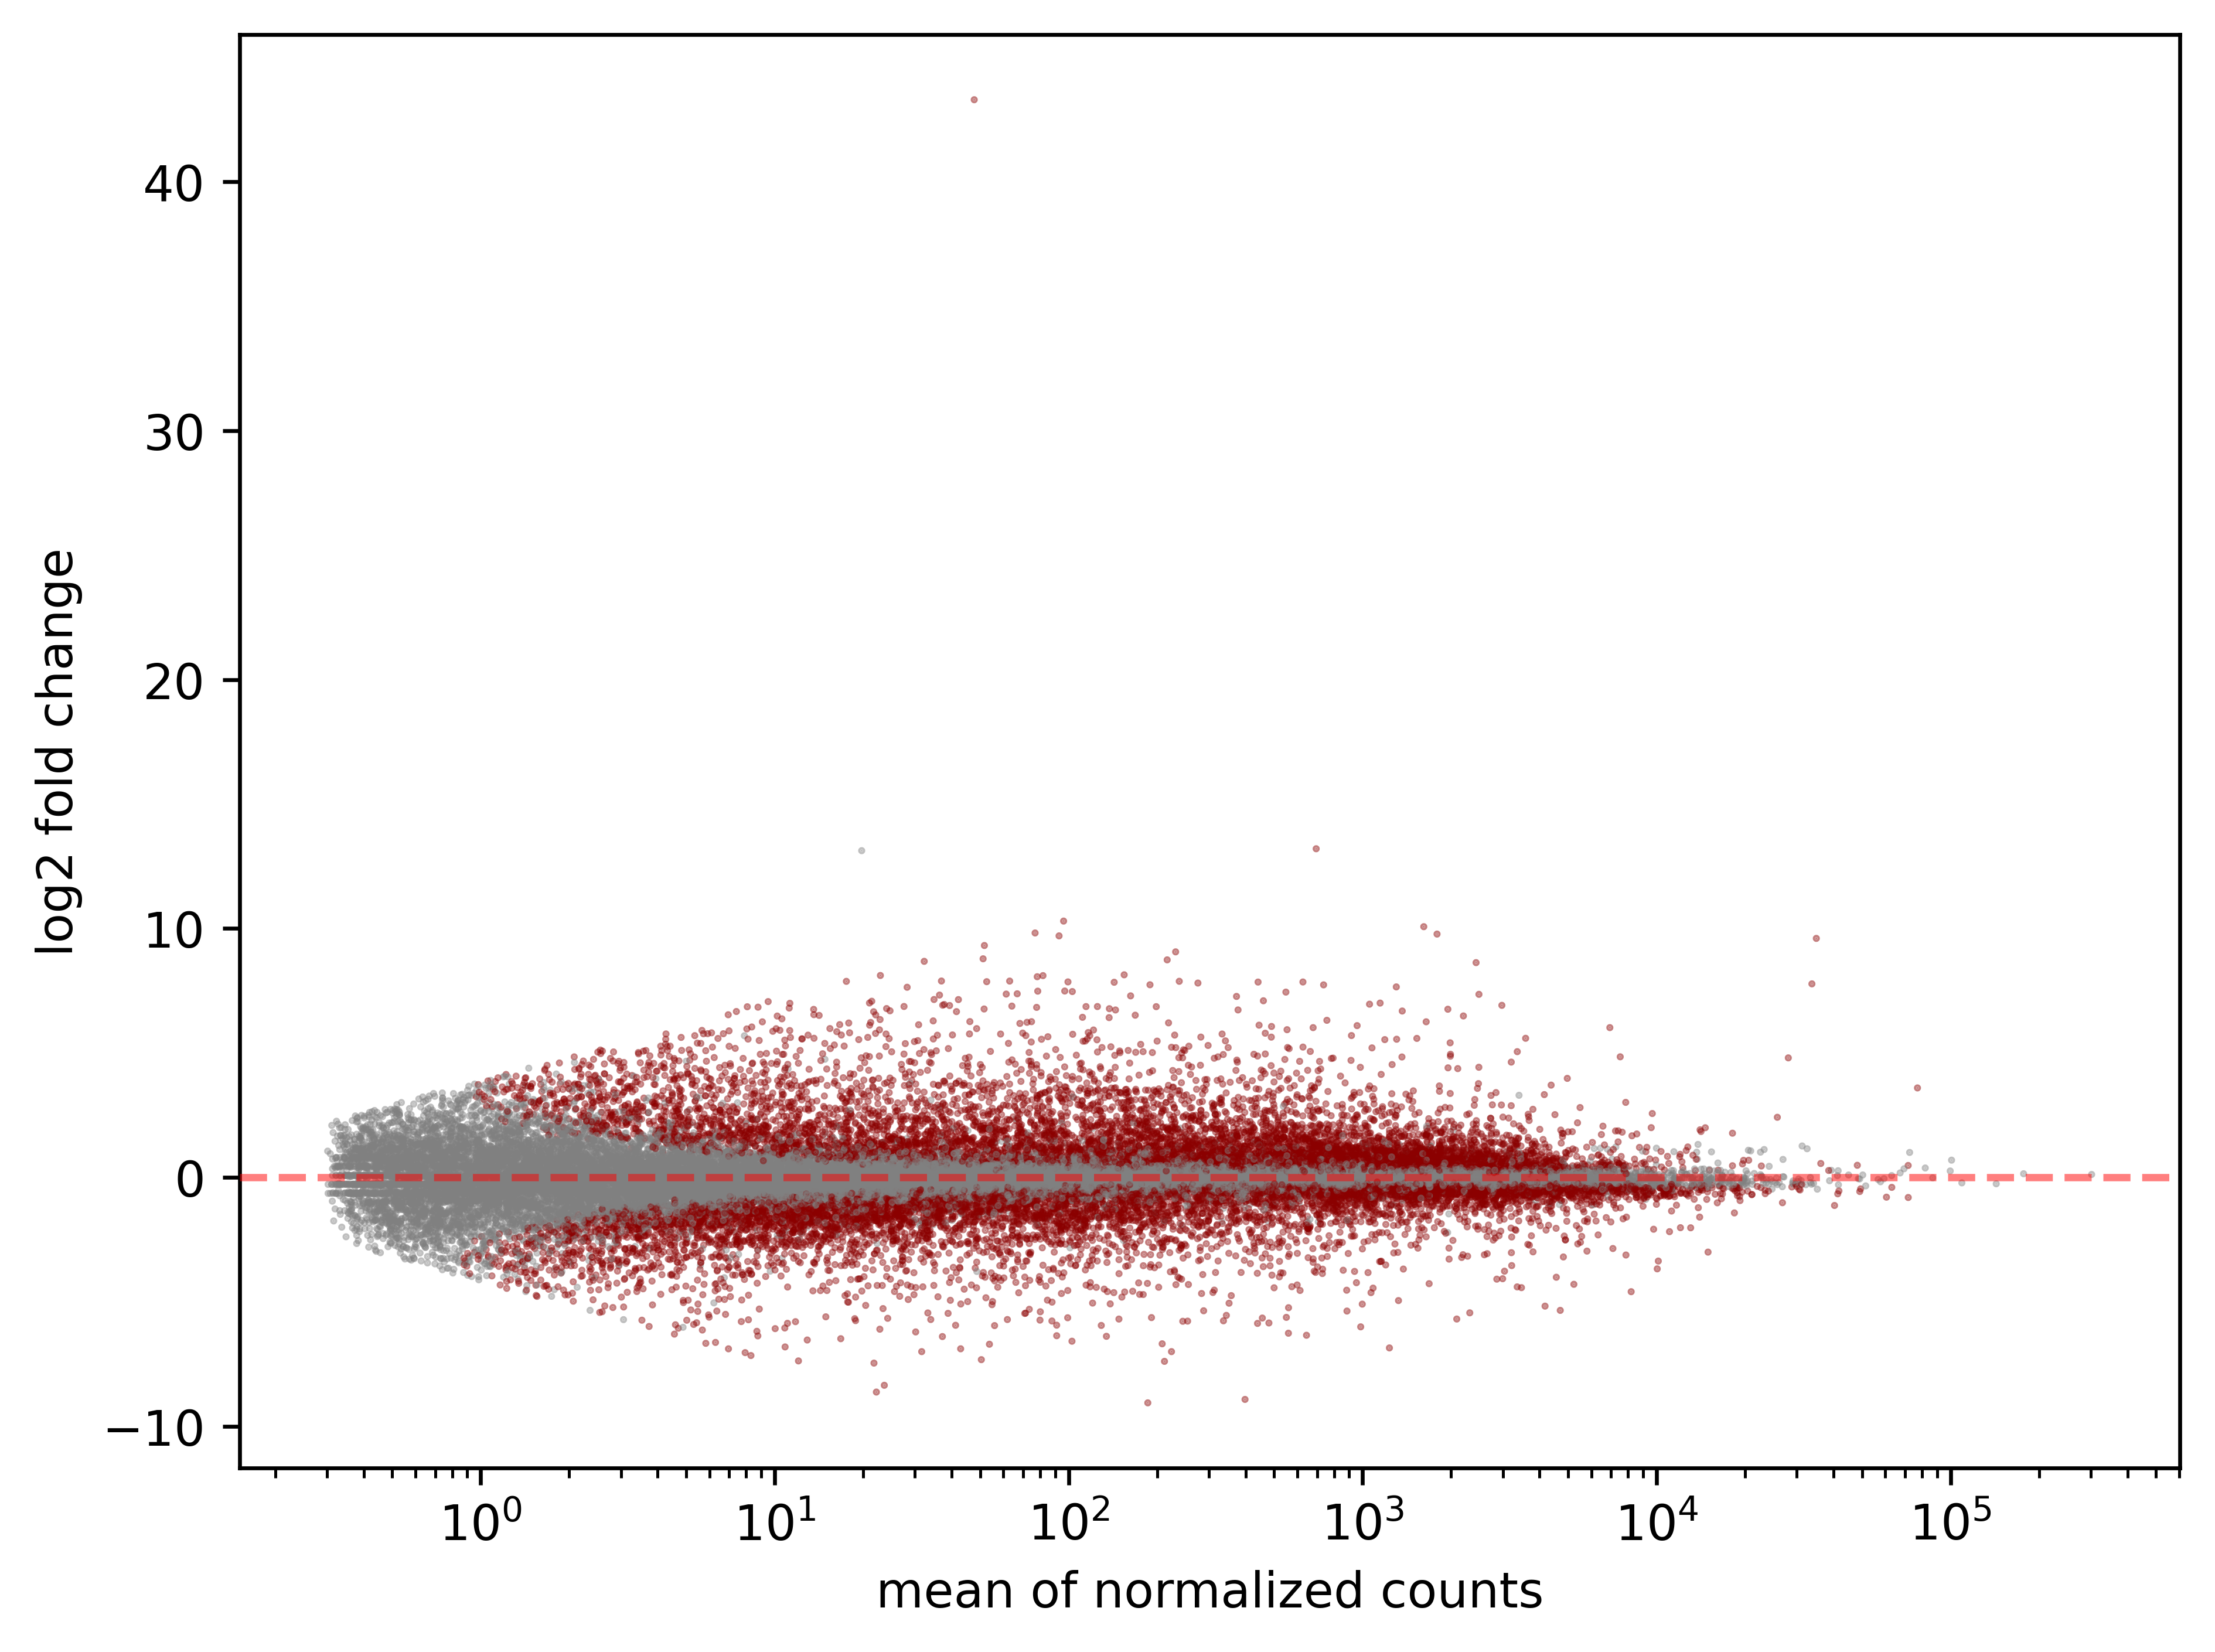

In [ ]:
results = run_deseq2_and_save(
    count_matrix=count_matrix,
    metadata=metadata,
    outdir=study,
    control_level=control_level,
    treated_level=treated_level,
)

## Next steps

The output directory now contains the DESeq2 results table and plots. You can use these files to inspect the most strongly differentially expressed genes, generate additional visualizations, or compare results across studies.